# RewardLoop: customer groups and reward preferences

This analysis uses only the generated event history from notebook 1. It groups customers by their app activity and calculates category evidence from reward interactions. The exported results power the portfolio dashboard.

Six groups are retained as an interpretable demonstration. Separation and sensitivity are measured below, but neither synthetic clusters nor simulated preferences establish real customer behavior.

## Setup and source

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'lib').exists() else Path.cwd().parent
DATA = ROOT / 'Data Analysis' / 'data'
OUTPUT = ROOT / 'Data Analysis' / 'output'
DATA.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)
SEED = 1729
plt.rcParams.update({'figure.figsize': (10, 4.5), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#0f766e','#2563eb','#d97706','#7c3aed','#be185d','#475569']
catalog = json.loads((ROOT / 'lib/reward-catalog.json').read_text())
category_names = list(dict.fromkeys(reward['category'] for reward in catalog))

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
events=pd.read_csv(DATA/'synthetic_events.csv',keep_default_na=False)
profile=json.loads((OUTPUT/'source_profile.json').read_text())
assert profile['synthetic'] is True
assert events.customer_id.str.startswith('SYN-').all()

## Customer activity measures

Event counts are aggregated to one row per customer. Session count, active days, average depth and activity shares describe behavior. Reward category is excluded from clustering, so the preference layer does not enter the clustering inputs. Hidden generator tendencies are not used as training labels.

In [2]:
counts=pd.crosstab(events.customer_id,events.event)
features=pd.DataFrame(index=counts.index)
features['total_events']=counts.sum(axis=1)
features['sessions']=events.groupby('customer_id').session_id.nunique()
features['active_days']=events.assign(day=events.timestamp.str[:10]).groupby('customer_id').day.nunique()
features['average_depth']=features.total_events/features.sessions
for event in ['home','voucher','detail','campaign','membership','dashboard','click']:
    features[event+'_share']=counts.get(event,0)/features.total_events
prepared=features.copy()
for column in ['total_events','sessions','active_days','average_depth']:
    prepared[column]=np.log1p(prepared[column])
scaler=StandardScaler()
X=scaler.fit_transform(prepared)
display(features.head().round(3))

,total_events,sessions,active_days,average_depth,home_share,voucher_share,detail_share,campaign_share,membership_share,dashboard_share,click_share
customer_id,,,,,,,,,,,
SYN-00001,31,4,4,7.75,0.000,0.0,0.097,0.516,0.0,0.129,0.097
SYN-00002,11,2,2,5.50,0.364,0.0,0.182,0.000,0.0,0.182,0.091
SYN-00003,5,2,2,2.50,0.000,0.0,0.200,0.000,0.0,0.400,0.200
SYN-00004,16,5,4,3.20,0.625,0.0,0.000,0.000,0.0,0.312,0.000
SYN-00005,1,1,1,1.00,0.000,0.0,0.000,0.000,0.0,1.000,0.000


## Comparing group counts

K-Means is fitted for three to eight groups using the same scaled inputs and seed. Silhouette compares within-group similarity with separation from other groups. The comparison uses the same customer sample for every candidate.

,groups,silhouette,inertia
0,3,0.2955,11550.9071
1,4,0.3594,9291.9743
2,5,0.4478,7093.6704
3,6,0.5335,4964.5067
4,7,0.5574,4095.8210
5,8,0.5227,3740.9246


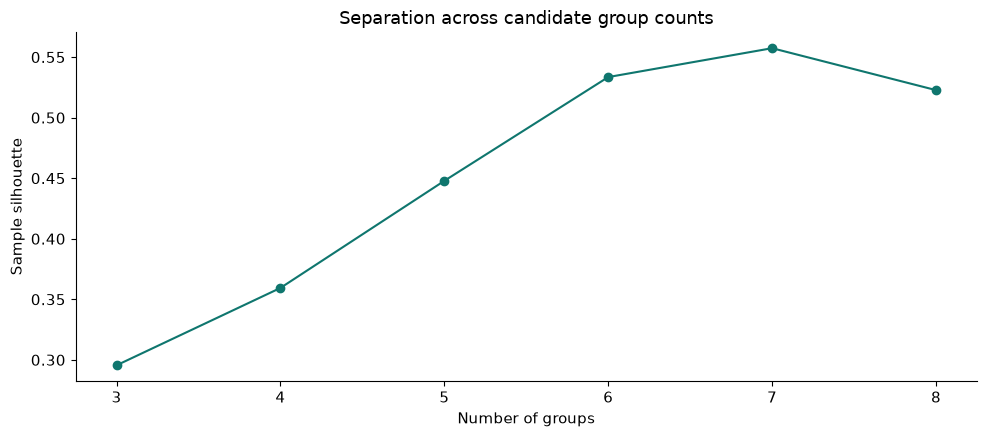

In [3]:
models={}; comparison=[]
for k in range(3,9):
    model=KMeans(n_clusters=k,n_init=10,random_state=SEED).fit(X)
    models[k]=model
    comparison.append(dict(groups=k,silhouette=float(silhouette_score(X,model.labels_,sample_size=min(1200,len(X)),random_state=SEED)),inertia=float(model.inertia_)))
comparison=pd.DataFrame(comparison)
display(comparison.round(4))
fig,ax=plt.subplots()
ax.plot(comparison.groups,comparison.silhouette,marker='o',color=COLORS[0])
ax.set(title='Separation across candidate group counts',xlabel='Number of groups',ylabel='Sample silhouette')
plt.tight_layout();plt.show()

## Naming and checking six groups

Names are assigned to the fitted group averages. A one-to-one matching rule links groups to home, voucher, detail, dashboard, campaign and membership activity. Names describe the dominant measured activity, not customer identity.

A second seed checks assignment sensitivity on this synthetic sample. Agreement across two seeds is a limited check, not evidence of stability on future real data.

,customers,share_percent
behavior_cluster,,
Casual Browsers,343,19.06
Status Seekers,308,17.11
Single-Glance Bouncers,292,16.22
Trigger Responders,288,16.00
Voucher Trackers,287,15.94
Deal Comparers,282,15.67


Two-seed adjusted Rand agreement: 1.000


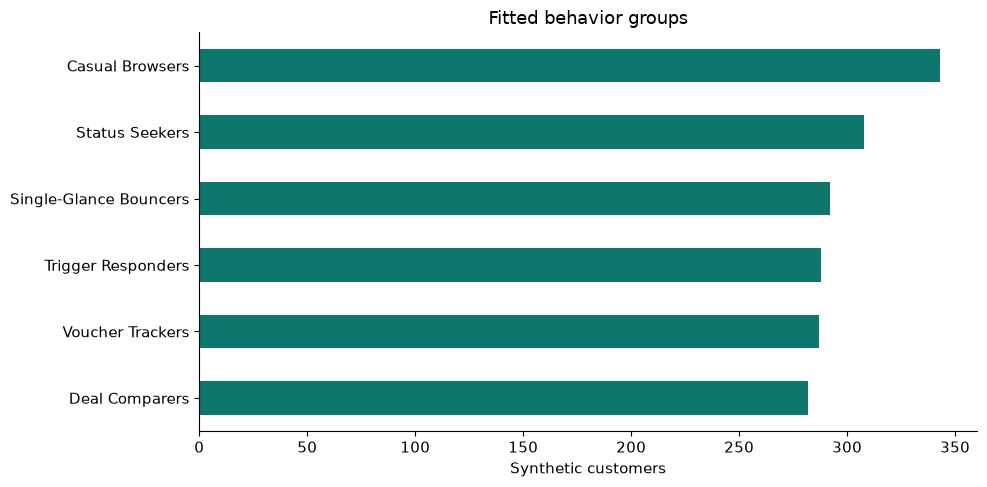

In [4]:
model=models[6]
raw_groups=pd.Series(model.labels_,index=features.index,name='group')
centroids=features.groupby(raw_groups).mean()
traits=['home_share','voucher_share','detail_share','dashboard_share','campaign_share','membership_share']
NAMES=['Casual Browsers','Voucher Trackers','Deal Comparers','Single-Glance Bouncers','Trigger Responders','Status Seekers']
IDS=['home','voucher','detail','skimmer','campaign','membership']
rows,cols=linear_sum_assignment(-centroids[traits].to_numpy())
name_map={int(row):NAMES[col] for row,col in zip(rows,cols)}
labels=raw_groups.map(name_map).rename('behavior_cluster')
summary=features.join(labels).groupby('behavior_cluster').mean()
sizes=labels.value_counts()
second=KMeans(n_clusters=6,n_init=10,random_state=SEED+1).fit(X)
stability=float(adjusted_rand_score(model.labels_,second.labels_))
display(pd.DataFrame({'customers':sizes,'share_percent':sizes/len(features)*100}).round(2))
print(f'Two-seed adjusted Rand agreement: {stability:.3f}')
fig,ax=plt.subplots(figsize=(10,5))
sizes.sort_values().plot.barh(ax=ax,color=COLORS[0])
ax.set(title='Fitted behavior groups',xlabel='Synthetic customers',ylabel='')
plt.tight_layout();plt.show()

## Category evidence

The fictional catalogue provides exact categories, avoiding keyword ambiguity. A deal click contributes 2 points, a detail view 3 points, a voucher visit 4 points and a redeem-screen visit 4 points. A customer is Known only with at least two category events, a leading category score of 6, a top share of 55%, and a margin of 15 percentage points (waived at a top share of 75%).

These are transparent demonstration rules. They are not confidence probabilities and do not prove what customers want.

,customers,share_percent
preference,,
Learning,1102,61.22
Shopping & Savings,106,5.89
Birthday & Seasonal,93,5.17
Membership & Exclusive,90,5.00
Sports & Wellness,86,4.78
Gaming & Tech,85,4.72
Entertainment & Streaming,81,4.50
Food & Dining,80,4.44
Travel & Roaming,77,4.28


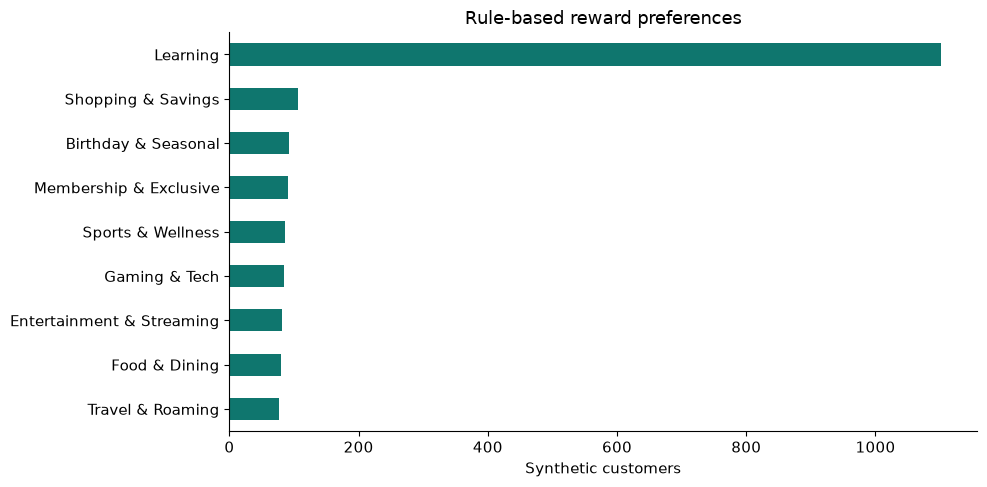

In [5]:
weights={'click':2,'detail':3,'voucher':4,'redeem':4}
signals=events[events.category.ne('') & events.event.isin(weights)].copy()
signals['score']=signals.event.map(weights)
scores=signals.pivot_table(index='customer_id',columns='category',values='score',aggfunc='sum',fill_value=0).reindex(index=features.index,columns=category_names,fill_value=0)
evidence=signals.groupby('customer_id').size().reindex(features.index,fill_value=0)
ordered=np.argsort(-scores.to_numpy(),axis=1,kind='stable')
values=scores.to_numpy(); positions=np.arange(len(values))
top=values[positions,ordered[:,0]]; second_score=values[positions,ordered[:,1]]
totals=values.sum(axis=1)
top_share=np.divide(top,totals,out=np.zeros(len(top),dtype=float),where=totals>0)
margin=np.divide(top-second_score,totals,out=np.zeros(len(top),dtype=float),where=totals>0)
known=(evidence.to_numpy()>=2)&(top>=6)&(top_share>=.55)&((margin>=.15)|(top_share>=.75))
prefs=pd.DataFrame({'behavior_cluster':labels,'top_preference':np.array(category_names)[ordered[:,0]],'second_preference':np.array(category_names)[ordered[:,1]],'signal_events':evidence,'score':totals,'top_score':top,'top_share':top_share,'margin':margin,'known':known},index=features.index)
prefs['preference']=np.where(known,prefs.top_preference,'Learning')
prefs['reason']=np.where(known,'graduated',np.where(evidence==0,'no_category_signal','insufficient_or_mixed_evidence'))
pref_counts=prefs.preference.value_counts()
display(pd.DataFrame({'customers':pref_counts,'share_percent':pref_counts/len(prefs)*100}).round(2))
fig,ax=plt.subplots(figsize=(10,5))
pref_counts.sort_values().plot.barh(ax=ax,color=COLORS[0])
ax.set(title='Rule-based reward preferences',xlabel='Synthetic customers',ylabel='')
plt.tight_layout();plt.show()

## Threshold sensitivity

In [6]:
sensitivity=[]
for minimum in [4,6,10,15]:
    selected=(evidence.to_numpy()>=2)&(top>=minimum)&(top_share>=.55)&((margin>=.15)|(top_share>=.75))
    sensitivity.append({'minimum_score':minimum,'known_customers':int(selected.sum()),'known_percent':float(selected.mean()*100)})
display(pd.DataFrame(sensitivity).round(2))

,minimum_score,known_customers,known_percent
0,4,889,49.39
1,6,698,38.78
2,10,544,30.22
3,15,436,24.22


## Behavior and preference together

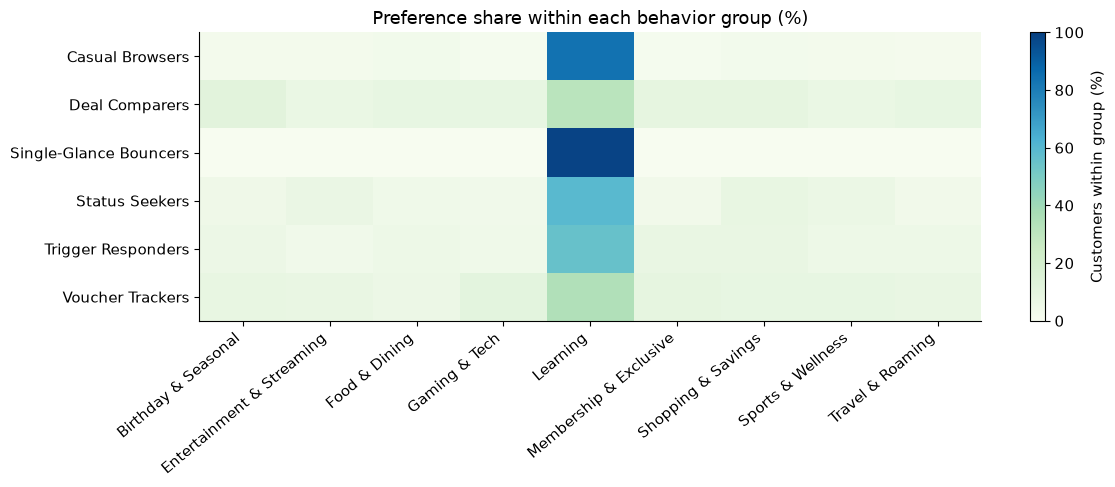

Each row uses its own behavior-group count as the denominator. The same browsing pattern can occur with several category interests.

In [7]:
matrix=pd.crosstab(prefs.behavior_cluster,prefs.preference,normalize='index')*100
fig,ax=plt.subplots(figsize=(12,5))
im=ax.imshow(matrix.values,aspect='auto',cmap='GnBu',vmin=0,vmax=100)
ax.set_yticks(range(len(matrix)),matrix.index)
ax.set_xticks(range(len(matrix.columns)),matrix.columns,rotation=40,ha='right')
ax.set_title('Preference share within each behavior group (%)')
fig.colorbar(im,ax=ax,label='Customers within group (%)');plt.tight_layout();plt.show()
display(Markdown('Each row uses its own behavior-group count as the denominator. The same browsing pattern can occur with several category interests.'))

## Dashboard export

The dashboard JSON is calculated from these tables and the source summary. No dashboard totals are entered by hand. Customer examples use synthetic IDs. Campaign suggestions are demonstration ideas rather than measured treatment effects.

In [8]:
round2=lambda x:round(float(x),2)
clusters=[]
for i,(name,cid,trait) in enumerate(zip(NAMES,IDS,traits)):
    row=summary.loc[name]
    clusters.append(dict(id=cid,name=name,shortName=name,users=int(sizes[name]),percent=round2(sizes[name]/len(prefs)*100),color=COLORS[i],behaviour=f"Synthetic group with relatively prominent {trait.replace('_share','')} activity.",signals=[f"{trait.replace('_share','').title()} events: {row[trait]:.1%} of customer activity"],rewardTypes='Test offers against category evidence',channel='In-app / Push',tone='Clear and helpful',toneExample='A reward selected for your next visit.',avgEvents=round2(row.total_events),avgSessions=round2(row.sessions),avgActiveDays=round2(row.active_days),dealClickRate=round2(row.click_share*100),dealDetailShare=round2(row.detail_share*100),voucherShare=round2(row.voucher_share*100),campaignShare=round2(row.campaign_share*100),topDrivers=[trait]))
category_events=events[events.category.ne('')]
category_summary=[]
for category,group in category_events.groupby('category'):
    category_summary.append(dict(category=category,events=len(group),users=int(group.customer_id.nunique()),sessions=int(group.session_id.nunique()),dealClicks=int(group.event.eq('click').sum()),value=round2(len(group)/len(category_events)*100)))
category_summary.sort(key=lambda x:-x['events'])
reward_summary=[]
for rid,group in category_events.groupby('reward_id'):
    reward=next(x for x in catalog if x['id']==rid)
    reward_summary.append(dict(name=reward['name'],category=reward['category'],events=len(group),users=int(group.customer_id.nunique()),sessions=int(group.session_id.nunique()),dealClicks=int(group.event.eq('click').sum())))
reward_summary.sort(key=lambda x:-x['dealClicks'])
all_clicks=sum(x['dealClicks'] for x in reward_summary)
unavailable=set(events.loc[events.event.eq('unavailable'),'session_id'])
last_events=events.sort_values(['session_id','sequence']).groupby('session_id').tail(1)
ended=int(last_events.event.eq('unavailable').sum())
daily=events.groupby(events.timestamp.str[:10]).size()
separation=float(comparison.loc[comparison.groups.eq(6),'silhouette'].iloc[0])
dashboard=dict(
 source=dict(file='synthetic_events.csv',sizeMB=round2((DATA/'synthetic_events.csv').stat().st_size/1024**2),generatedAt='2025-02-15T00:00:00Z',timezone='Simulated local time',grain='One generated app event per row; one customer per clustering row.',funnelValidatedAt='Recomputed from synthetic events',isSynthetic=True,seed=SEED),
 dataset=dict(totalEvents=len(events),uniqueUsers=len(prefs),sessions=int(events.session_id.nunique()),dateRange=f"{daily.index.min()} to {daily.index.max()}",minDate=daily.index.min(),maxDate=daily.index.max(),days=len(daily)),
 quality=dict(exactDuplicateRows=int(events.duplicated().sum()),exactDuplicateShare=0,duplicateEventKeys=int(events.duplicated(['session_id','sequence']).sum()),networkLineTypeMissingShare=0,cleanScreenCoverage=100,missingEventDates=[]),
 clusterModel=dict(method='K-Means on synthetic behavioral measures',variant='Six groups for interpretation',clusters=6,coverage=100,sampleSilhouette=separation,selectionSilhouette=float(comparison.silhouette.max()),inertiaPerCustomer=float(model.inertia_/len(prefs)),comparedKValues=len(comparison),seedAgreement=stability,features=len(features.columns)),
 clusters=clusters,dailyEvents=[dict(date=date,events=int(count)) for date,count in daily.items()],funnelStages=profile['funnel'],categoryEngagement=category_summary,
 dealConcentration=dict(top10=round2(sum(x['dealClicks'] for x in reward_summary[:10])/all_clicks*100),top20=round2(sum(x['dealClicks'] for x in reward_summary[:20])/all_clicks*100),namedDealClicks=all_clicks),
 unavailableJourney=dict(sessions=len(unavailable),endedAtUnavailable=ended,droppedAfter=round2(ended/max(1,len(unavailable))*100)),topDeals=reward_summary[:15])

In [9]:
preference_clusters=[]
category_ids=['food','travel','gaming','entertainment','wellness','membership','seasonal','savings']
for category,cid in [('Learning','learning')]+list(zip(category_names,category_ids)):
    group=prefs[prefs.preference.eq(category)]
    preference_clusters.append(dict(id=cid,name=category,description='Insufficient or mixed evidence under the demo rules.' if category=='Learning' else f'Recorded interactions with fictional {category.lower()} offers.',push='Test a relevant offer; measure outcomes separately.',examples=[x['name'] for x in catalog if x['category']==category][:3] or ['Choose interests','Explore categories'],customers=len(group),share=round2(len(group)/len(prefs)*100),avgSignalEvents=round2(group.signal_events.mean()) if len(group) else 0,avgScore=round2(group.score.mean()) if len(group) else 0,avgTopShare=round2(group.top_share.mean()*100) if len(group) else 0,avgMargin=round2(group.margin.mean()*100) if len(group) else 0))
behavior_preferences=[]
for name,group in prefs.groupby('behavior_cluster'):
    known_counts=group[group.known].preference.value_counts()
    behavior_preferences.append(dict(behaviorCluster=name,customers=len(group),learningShare=round2((~group.known).mean()*100),topPreferences=[dict(name=k,customers=int(v),share=round2(v/len(group)*100)) for k,v in known_counts.head(3).items()]))
examples=[]
for category,group in prefs.groupby('preference'):
    for cid,row in group.head(2).iterrows():
        examples.append(dict(customerId=cid,behaviorCluster=row.behavior_cluster,preferenceCluster=row.preference,topPreference=row.top_preference,secondPreference=row.second_preference,topShare=round2(row.top_share*100),margin=round2(row.margin*100),signalEvents=int(row.signal_events),learningReason=row.reason))
preference=dict(model=dict(method='Catalogue category scores on synthetic events',scope='Separate descriptive layer; no category inputs in clustering',minimumScore=6,minimumSignalEvents=2,minimumTopShare=55,minimumMargin=15,categories=category_names,interactionWeights=weights),coverage=dict(customers=len(prefs),knownCustomers=int(known.sum()),knownShare=round2(known.mean()*100),learningCustomers=int((~known).sum()),learningShare=round2((~known).mean()*100),noSignalCustomers=int((evidence==0).sum()),ambiguousCustomers=int(((~known)&(evidence.to_numpy()>0)).sum()),classifiedEvents=len(signals),classifiedEventShare=round2(len(signals)/len(events)*100)),clusters=preference_clusters,behaviorPreferenceSummary=behavior_preferences,sampleProfiles=examples,learningExperiments=[dict(name='Choose interests',design='Offer a choice of fictional reward categories',signal='Selected category',next='Compare stated choices with later interactions'),dict(name='Try different rewards',design='Randomise one eligible exploration slot',signal='Views and clicks per exposure',next='Compare with a control group'),dict(name='Compare message styles',design='Keep the offer fixed and vary the copy',signal='Clicks per message exposure',next='Estimate the difference between groups'),dict(name='Learn from later activity',design='Revisit preferences after more events',signal='New category evidence',next='Recalculate the same evidence rules')],graduationRule='At least two category events, top score 6, top share 55%, and margin 15 percentage points (waived at top share 75%).',caveat='Entirely synthetic data. Category scores and group labels demonstrate a method; they do not establish real customer preferences or business lift.')
(ROOT/'lib/dashboard-data.json').write_text(json.dumps(dashboard,indent=2))
(ROOT/'lib/preference-dashboard-data.json').write_text(json.dumps(preference,indent=2))
features.join(labels).to_csv(OUTPUT/'customer_features.csv')
prefs.to_csv(OUTPUT/'customer_preferences.csv')
comparison.to_csv(OUTPUT/'cluster_comparison.csv',index=False)
pd.DataFrame(sensitivity).to_csv(OUTPUT/'threshold_sensitivity.csv',index=False)

## Reconciliation and findings

In [10]:
assert sum(c['users'] for c in dashboard['clusters'])==len(prefs)==profile['customers']
assert sum(c['customers'] for c in preference['clusters'])==len(prefs)
assert sum(x['events'] for x in dashboard['dailyEvents'])==len(events)==profile['events']
assert preference['coverage']['knownCustomers']+preference['coverage']['learningCustomers']==len(prefs)
assert all(r['customerId'].startswith('SYN-') for r in examples)
assert json.loads((ROOT/'lib/dashboard-data.json').read_text())==dashboard
assert json.loads((ROOT/'lib/preference-dashboard-data.json').read_text())==preference
best=int(comparison.loc[comparison.silhouette.idxmax(),'groups'])
display(Markdown(f"The synthetic history contains **{len(events):,} events** from **{len(prefs):,} customers**. The six-group model has a sample silhouette of **{separation:.3f}**; the highest tested score occurs at **{best} groups**. Two-seed agreement is **{stability:.3f}**. Under the selected category rules, **{known.mean():.1%}** of customers are Known and **{(~known).mean():.1%}** remain Learning. These results describe the generated data only."))
print('All source, customer, preference and dashboard totals agree.')

The synthetic history contains **54,823 events** from **1,800 customers**. The six-group model has a sample silhouette of **0.534**; the highest tested score occurs at **7 groups**. Two-seed agreement is **1.000**. Under the selected category rules, **38.8%** of customers are Known and **61.2%** remain Learning. These results describe the generated data only.

All source, customer, preference and dashboard totals agree.


## Interpretation limits

The browsing tendencies and progression probabilities were chosen for this demonstration. A model finding those patterns is not evidence of performance on real data. The category scores reflect exposure and repeated activity, not a verified statement of interest. Redeem-screen visits are not completed redemptions. Campaign copy and simulator interactions demonstrate product behavior but do not establish personalisation lift.